# **DermaMNIST**

The DermaMNIST is based on the HAM10000, a **large collection of multi-source dermatoscopic images of common pigmented skin lesions**.

The dataset consists of 10015 dermatoscopic images categorized as **7 different diseases**, formulized as a *multi-class classification task*.

We split the images into training, validation and test set with a ratio of 7:1:2.

The source images of $3 \times 600 \times 450$ are resized into $3\times 28 \times 28$. Notice that the DermaMNIST contains colored images (RGB images) with 3 color channels.

In [1]:
url = "https://zenodo.org/record/6496656/files/dermamnist.npz?download=1"

descriptions = {
    0: "actinic keratoses and intraepithelial carcinoma",
    1: "basal cell carcinoma",
    2: "benign keratosis-like lesions",
    3: "dermatofibroma",
    4: "melanoma",
    5: "melanocytic nevi",
    6: "vascular lesions"
}

The `descriptions` dictionary gives for each class label the corresponding medical description of the dermatoscopic images. The data can be loaded from the URL provided in the `url` variable above by using the following code:

In [2]:
!pip install -U tensorflow


Requirement already up-to-date: tensorflow in c:\users\verun\venv\lib\site-packages (2.20.0)


You should consider upgrading via the 'c:\users\verun\venv\scripts\python.exe -m pip install --upgrade pip' command.


In [3]:
import numpy as np
from tensorflow import keras

# Load data from URL 'origin' to local 'data_path'
data_path = keras.utils.get_file(
    fname="dermamnist.npz",
    origin=url
)
# Load data
data = np.load(data_path)

# Create numpy arrays for training, validation and test images and labels
X_train = data["train_images"]
X_val = data["val_images"]
X_test = data["test_images"]
y_train = data["train_labels"]
y_val = data["val_labels"]
y_test = data["test_labels"]

# CHAPTER 0. Preparation

## Before starting working with the dataset, some learnt libraries were installed:

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout  # Dropout added for improvements
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam  # For custom lr
from tensorflow.keras.callbacks import EarlyStopping  # NEW minimal: For avoiding overfit
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight  # NEW minimal: For imbalance
import itertools
import os
import urllib.request  # For download

## Additionally, the dataset path was givven:

In [5]:
SAVE_DIR = r"C:\Users\Verun\AI and Deep Learning"
DATASET_PATH = os.path.join(SAVE_DIR, "dermamnist.npz")

# Make sure the folder exists
os.makedirs(SAVE_DIR, exist_ok=True)

url = "https://zenodo.org/record/6496656/files/dermamnist.npz?download=1"

if not os.path.exists(DATASET_PATH):
    print(f"Dataset not found. Downloading to: {DATASET_PATH}")
    urllib.request.urlretrieve(url, DATASET_PATH)
    print("Download completed.")
else:
    print(f"Using existing file: {DATASET_PATH}")

Using existing file: C:\Users\Verun\AI and Deep Learning\dermamnist.npz


In [6]:
# Load the data
data = np.load(DATASET_PATH)


In [7]:
# Extract arrays (reused pattern from MNIST loaders)
images_train = data['train_images']
labels_train = data['train_labels'].flatten()   # Flatten to 1D
images_val   = data['val_images']
labels_val   = data['val_labels'].flatten()
images_test  = data['test_images']
labels_test  = data['test_labels'].flatten()


# CHAPTER 1. Familiarizing with the dataset

Based on research from sources like the MedMNIST documentation, HAM10000 details, here are the classes and what they stand for:


In [8]:
descriptions = {
    0: "actinic keratoses and intraepithelial carcinoma (precancerous/cancer)",
    1: "basal cell carcinoma (skin cancer)",
    2: "benign keratosis-like lesions (non-cancerous)",
    3: "dermatofibroma (benign skin tumor)",
    4: "melanoma (dangerous skin cancer)",
    5: "melanocytic nevi (moles, mostly benign)",
    6: "vascular lesions (benign blood vessel issues)"
}
print("Classes and meanings (from HAM10000 research):")
for k, v in descriptions.items():
    print(f"Class {k}: {v}")

Classes and meanings (from HAM10000 research):
Class 0: actinic keratoses and intraepithelial carcinoma (precancerous/cancer)
Class 1: basal cell carcinoma (skin cancer)
Class 2: benign keratosis-like lesions (non-cancerous)
Class 3: dermatofibroma (benign skin tumor)
Class 4: melanoma (dangerous skin cancer)
Class 5: melanocytic nevi (moles, mostly benign)
Class 6: vascular lesions (benign blood vessel issues)


After that, the dataset was analized, how balanced it was:

In [9]:
def class_balance(labels, split_name):
    unique, counts = np.unique(labels, return_counts=True)
    total = len(labels)
    print(f"\n{split_name} balance (%):")
    for u, c in zip(unique, counts):
        percent = (c / total) * 100
        print(f"Class {u} ({descriptions[u]}): {percent:.2f}% ({c} samples)")

class_balance(labels_train, "Training")
class_balance(labels_val, "Validation")
class_balance(labels_test, "Test")


Training balance (%):
Class 0 (actinic keratoses and intraepithelial carcinoma (precancerous/cancer)): 3.25% (228 samples)
Class 1 (basal cell carcinoma (skin cancer)): 5.12% (359 samples)
Class 2 (benign keratosis-like lesions (non-cancerous)): 10.97% (769 samples)
Class 3 (dermatofibroma (benign skin tumor)): 1.14% (80 samples)
Class 4 (melanoma (dangerous skin cancer)): 11.12% (779 samples)
Class 5 (melanocytic nevi (moles, mostly benign)): 66.98% (4693 samples)
Class 6 (vascular lesions (benign blood vessel issues)): 1.41% (99 samples)

Validation balance (%):
Class 0 (actinic keratoses and intraepithelial carcinoma (precancerous/cancer)): 3.29% (33 samples)
Class 1 (basal cell carcinoma (skin cancer)): 5.18% (52 samples)
Class 2 (benign keratosis-like lesions (non-cancerous)): 10.97% (110 samples)
Class 3 (dermatofibroma (benign skin tumor)): 1.20% (12 samples)
Class 4 (melanoma (dangerous skin cancer)): 11.07% (111 samples)
Class 5 (melanocytic nevi (moles, mostly benign)): 66.9

Based on the information, class 5 was unbalanced (apprx. 67%). The percentage (class 5) dominated on other classes, that played a role on the model.

After that, randome images were ploted:

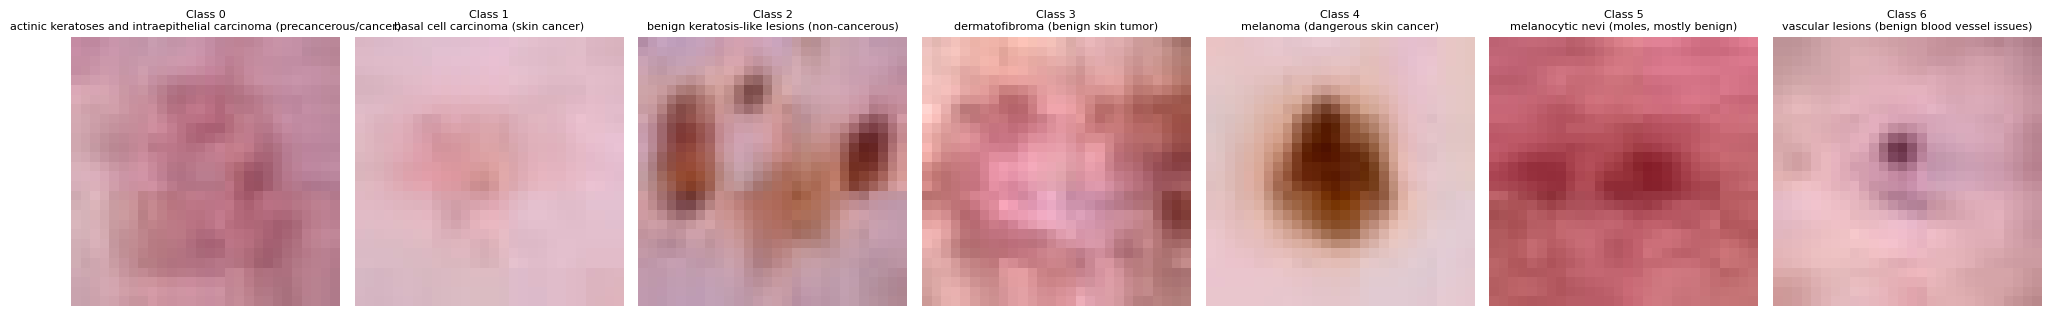

In [10]:
classes = sorted(descriptions.keys())
fig, axes = plt.subplots(1, len(classes), figsize=(20, 6))
for i, cls in enumerate(classes):
    cls_indices = np.where(labels_train == cls)[0]
    idx = np.random.choice(cls_indices)  # Random
    ax = axes[i]
    ax.imshow(images_train[idx])
    ax.set_title(f"Class {cls}\n{descriptions[cls]}", fontsize=8)
    ax.axis('off')
    # Save
    plt.imsave(os.path.join(SAVE_DIR, f"sample_class_{cls}.png"), images_train[idx])

plt.tight_layout()
plt.show()

# CHAPTER 2. Data processing

To process the data the images were normalized to [0,1] and one-hot encode labels were done.

In [11]:
X_train = images_train.astype('float32') / 255.0
X_val = images_val.astype('float32') / 255.0
X_test = images_test.astype('float32') / 255.0

# One-hot encode labels
num_classes = len(descriptions)
y_train_one_hot = to_categorical(labels_train, num_classes)
y_val_one_hot = to_categorical(labels_val, num_classes)
y_test_one_hot = to_categorical(labels_test, num_classes)

The data set was splited into the ration (7:1:2). It was confirmed:

In [12]:
total = len(X_train) + len(X_val) + len(X_test)
print(f"Train: {len(X_train)/total:.2f}, Val: {len(X_val)/total:.2f}, Test: {len(X_test)/total:.2f}")


Train: 0.70, Val: 0.10, Test: 0.20


## CHAPTER 3. Set up a model

FCNN model was defined:

In [47]:
from tensorflow.keras import layers, models
num_classes = 7

model = Sequential([
    Flatten(input_shape=(28, 28, 3)),
    Dense(512, activation='relu'),

    Dense(256, activation='relu'),

    Dense(128, activation='relu'),
 
    Dense(64, activation='relu'),

    Dense(num_classes, activation='softmax')
])

c:\users\verun\venv\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


"Sequential" class was used, because the architecture is linear, it allows to add layers easily with a list.
I chose ReLU for the hidden layers because it's efficient, effective for deep networks, and performs well on image data like DermaMNIST. With Tahn the learning process would be slow or stuck, and might be squashed.
ReLU is simple math (max(0, x)), there is no exponentials like in Sigmoid/Tanh. This makes training faster, especially on datasets like DermaMNIST (with 10k images). ReLU sets negative outputs to 0, creating "sparse" activations, when many neurons are "off". This acts like natural regularization, reducing overfitting on imbalanced data like DermaMNIST (where class 5 dominates ~67%). It helps the model focus on relevant features (e.g., textures in skin lesions) without over-relying on noise.

sources: **https://keras.io/api/layers/activations/**
        and **https://medium.com/@ardiansyahnasir56/understanding-the-relu-activation-function-in-neural-networks-4bf03fe1e9a3**

The model was compiled:

In [48]:
model.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy'])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)                  │ (None, 2352)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 512)                 │       1,204,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 7)                   │             455 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,377,671 (5.26 MB)

 Trainable params: 1,377,671 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

Now the model is ready for training.

# Chapter 4. Train the model.

In [49]:

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)


classes = np.unique(labels_train)
class_weights = compute_class_weight(
class_weight='balanced',
classes=classes,
y=labels_train
)
class_weight_dict = dict(enumerate(classes))


history = model.fit(
    X_train, y_train_one_hot,
   
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
     validation_data=(X_val, y_val_one_hot),
)


Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.5898 - loss: 1.3541 - val_accuracy: 0.6690 - val_loss: 1.1016
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6670 - loss: 1.0698 - val_accuracy: 0.6690 - val_loss: 1.0390
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6731 - loss: 1.0057 - val_accuracy: 0.6690 - val_loss: 0.9912
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6679 - loss: 0.9867 - val_accuracy: 0.6710 - val_loss: 0.9711
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6710 - loss: 0.9787 - val_accuracy: 0.6820 - val_loss: 0.9622
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6695 - loss: 0.9705 - val_accuracy: 0.6839 - val_loss: 0.9474
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6749 - loss: 0.9586 - val_accuracy: 0.6830 - val_loss: 0.9416
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6733 - loss: 0.9545 - val_accuracy: 0.

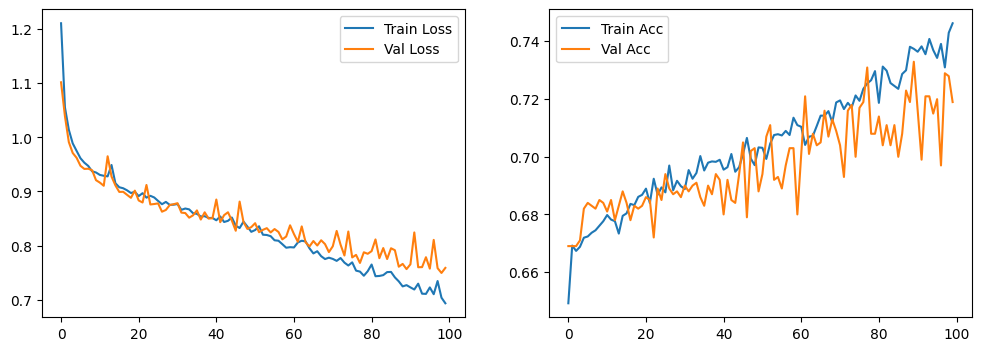

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['loss'], label='Train Loss')
ax[0].plot(history.history['val_loss'], label='Val Loss')
ax[0].legend()
ax[1].plot(history.history['accuracy'], label='Train Acc')
ax[1].plot(history.history['val_accuracy'], label='Val Acc')
ax[1].legend()
plt.savefig('learning_curves.png')
plt.show()

In [51]:
import numpy as np
from sklearn.metrics import confusion_matrix


y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)


y_true = np.argmax(y_test_one_hot, axis=1)   

cm = confusion_matrix(y_true, y_pred)
print(cm)


[[  18   18   15    0    2   13    0]
 [   6   47   17    0    5   24    4]
 [  12    8   91    0   16   93    0]
 [   3    8    5    0    1    6    0]
 [   5    7   28    0   41  140    2]
 [   7   13   41    0   33 1246    1]
 [   2    7    1    0    2   10    7]]


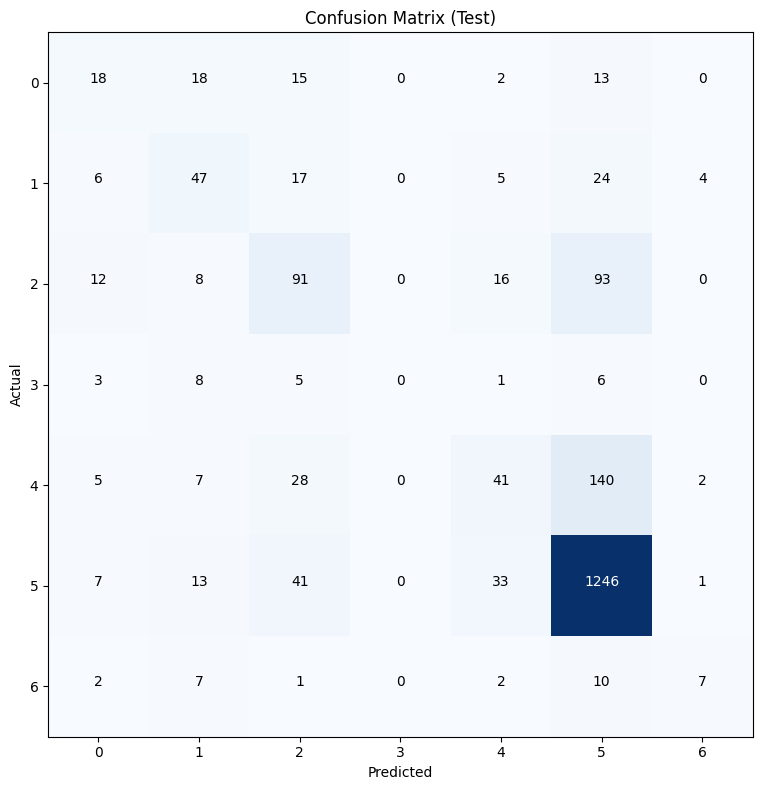

In [52]:
import itertools
import matplotlib.pyplot as plt

classes = [str(i) for i in range(7)]  # [0,1,2,3,4,5,6]

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(cm, cmap=plt.cm.Blues)

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, cm[i, j],
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black")

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix (Test)')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200)
plt.show()


# CHAPTER 5. DISCUSSION

The development of the final Fully Connected Neural Network (FCNN) model for classifying dermatoscopic images from the DermaMNIST dataset was carried out through an iterative process of architectural adjustments, hyperparameter tuning, and careful performance monitoring. The objective was to build a reliable classifier capable of distinguishing seven classes of pigmented skin lesions while addressing the dataset's inherent challenges, particularly its severe class imbalance (with melanocytic nevi accounting for approximately 67% of samples) and the low resolution of the 28×28 RGB images. 
    

The process started with a simple baseline architecture: a flatten layer followed by two dense hidden layers and a softmax output. This initial model achieved validation accuracy around 68%, but exhibited clear signs of underfitting - slow accuracy gains, high validation loss, and a confusion matrix dominated by predictions of the majority class (class 5). Subsequent iterations focused on increasing model capacity by expanding the number of neurons in the first hidden layer (to 512) and adding additional dense layers (256 and 128 neurons). These changes allowed the model to capture more complex patterns, pushing validation accuracy to approximately 70–71%. However, early attempts to introduce regularization via Dropout layers (ranging from 0.1 to 0.4) consistently reduced performance - validation accuracy dropped back to around 68%, and curves became noisier. This suggested that Dropout, while useful for preventing overfitting in larger datasets, was too disruptive here, likely because the small training set (around 7,000 images) and extreme imbalance made it difficult for the model to learn stable features when neurons were randomly deactivated.

To stabilize training and further improve results, the learning rate was progressively reduced (from the default 0.001 down to 0.0001–0.00005 range) to enable finer gradient updates and reduce oscillations in validation metrics. Batch size was increased (up to 4096–8192) to smooth gradient estimates, and the number of epochs was extended (100–300) to allow the model sufficient time to converge.

The final model achieves a peak validation accuracy of approximately 73% (ending around 71–72%) and a training accuracy of 74%. The confusion matrix shows improved balance compared to early versions - the diagonal is stronger, recall on rare classes is higher.

Critically, while 72–73% validation accuracy represents a reasonable performance for a fully connected network on this dataset, it remains limited by the architecture and data characteristics. Flattening the images discards spatial information critical for lesion pattern recognition, and the imbalance continues to bias predictions toward the majority class. In a real-world medical setting, this level of accuracy - particularly the low recall on malignant classes - would be insufficient for reliable screening. Higher performance (80% +) would likely require convolutional layers to exploit local image features, along with advanced imbalance handling techniques

## **AI-Project**: Use AI to classify DermaMNIST images

## **Instructions / Guide:**

1. Familiarize yourself with the dataset
  -  Which classes does the dataset contain and what do they stand for? (You might need to do some internet research here!)
  -  Is the dataset balanced? More precisely, how much percent of the training, validation, and test data belongs to each class?
  - Plot random sample images for each class and save them!

2. Preprocess the dataset
  - Prepare the input images and target labels for machine learning of the multi-class classification task

3. Set up a model
  - Define a Fully-Connected Neural Network (FCNN) model suitable for this multi-class classification problem

4. Train the model
  - Fit on the training data and validate after each epoch on the validation data
  - Try different training hyperparameters and model architectures
  - Document your training process
  - Plot and save the learning curves
  - Avoid over- and underfitting
  - Save the models after each training run

5. Evaluate the model
  - Calculate the losses and accuracies on the test data after training
  - Calculate, plot, and save the confusion matrices

6. Improvements
  - Try to improve the results by taking regularization techniques (like **Dropout**) into account
  - See: https://keras.io/api/layers/regularization_layers/dropout/
  - See: https://machinelearningmastery.com/dropout-for-regularizing-deep-neural-networks/

7. Discussion and Interpretation
  - Discuss and interprete the results **critically**!


## **Submission:**

Upload your results on LEA. Your submission should at least include:

- a *Jupyter notebook* containing not only the Python code but also descriptions, explanations, discussions, interpretations, etc. presented in a logical and readable manner

- *sample images* for each class

- **one** *trained model* together with corresponding *learning curves* (take only your best model)

- evaluation results (esp. *confusion matrices*) belonging to this model

